# Enterprise AI Credit Risk Intelligence Platform
## Exploratory Data Analysis & Banking Risk Insights

This notebook explores the Home Credit Default Risk dataset (307,511 records, 122+ features) and uncovers the 5 core quantitative drivers of borrower default risk.

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path
sys.path.append('..')
from src.data.loader import DataLoader
from src.data.preprocessor import DataPreprocessor

plt.style.use('dark_background')
%matplotlib inline

### 1. Ingestion & Data Profile

In [2]:
loader = DataLoader()
df_raw = loader.load_raw_dataframe()
print(f"Dataset Shape: {df_raw.shape}")
print("Target Distribution:")
print(df_raw['TARGET'].value_counts(normalize=True))

[2026-09-06 13:23:48] [INFO] [DataLoader]: Initialized DuckDB in-memory database instance.


[2026-09-06 13:23:48] [INFO] [DataLoader]: Loading raw DataFrame from application_train.csv (max_rows=50000)...


[2026-09-06 13:23:49] [INFO] [DataLoader]: Loaded DataFrame with shape: (50000, 122)


Dataset Shape: (50000, 122)
Target Distribution:
TARGET
0    0.91948
1    0.08052
Name: proportion, dtype: float64


### 2. Feature Engineering Banking Ratios

In [3]:
preprocessor = DataPreprocessor()
df_eng = preprocessor.engineer_features(df_raw)
df_eng[['PAYMENT_RATE', 'INCOME_CREDIT_PERC', 'ANNUITY_INCOME_PERC', 'EXT_SOURCES_MEAN']].describe()

,PAYMENT_RATE,INCOME_CREDIT_PERC,ANNUITY_INCOME_PERC,EXT_SOURCES_MEAN
count,49999.000000,50000.000000,49999.000000,49956.000000
mean,0.053623,0.402584,0.181018,0.509545
std,0.022467,0.986857,0.095025,0.149382
min,0.022077,0.011801,0.000224,0.000132
25%,0.036732,0.193548,0.114606,0.414256
50%,0.050000,0.304103,0.163075,0.524743
75%,0.063900,0.494462,0.229447,0.623055
max,0.124429,208.003328,1.875965,0.878903


### 3. Key Banking Insight 1: Composite External Bureau Score (EXT_SOURCES_MEAN)

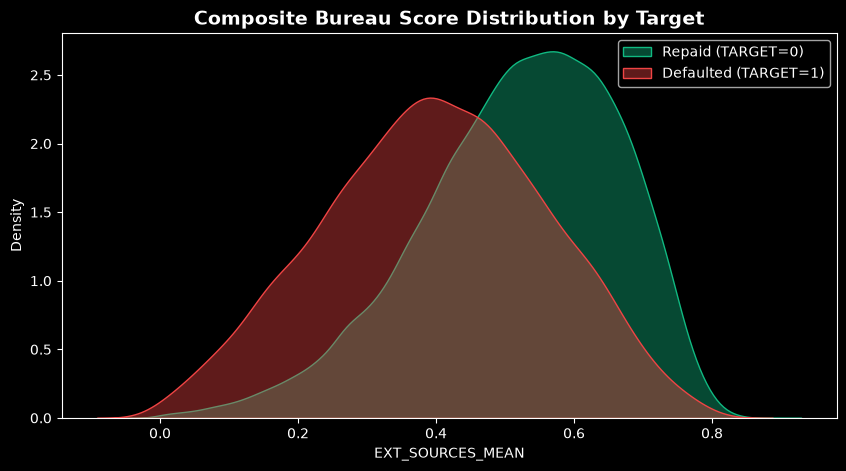

In [4]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_eng[df_eng['TARGET'] == 0]['EXT_SOURCES_MEAN'].dropna(), label='Repaid (TARGET=0)', color='#10B981', fill=True, alpha=0.4)
sns.kdeplot(df_eng[df_eng['TARGET'] == 1]['EXT_SOURCES_MEAN'].dropna(), label='Defaulted (TARGET=1)', color='#EF4444', fill=True, alpha=0.4)
plt.title('Composite Bureau Score Distribution by Target', fontsize=14, fontweight='bold')
plt.xlabel('EXT_SOURCES_MEAN')
plt.legend()
plt.show()

### 4. Key Banking Insight 2: Age Cohort Default Rate

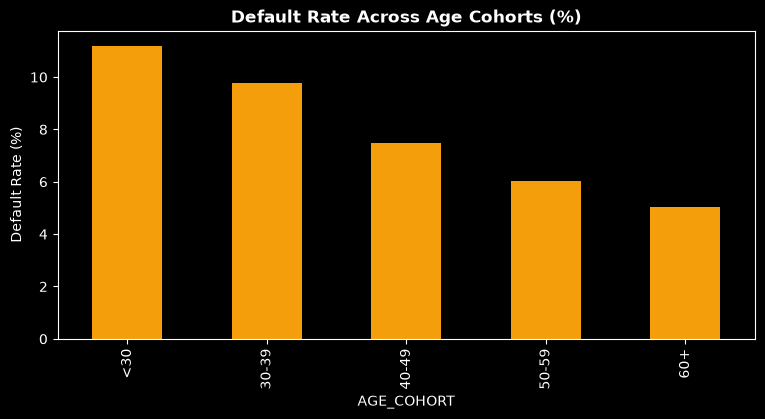

In [5]:
df_eng['AGE_COHORT'] = pd.cut(df_eng['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 100], labels=['<30', '30-39', '40-49', '50-59', '60+'])
age_risk = df_eng.groupby('AGE_COHORT', observed=False)['TARGET'].mean() * 100
plt.figure(figsize=(9, 4))
age_risk.plot(kind='bar', color='#F59E0B')
plt.title('Default Rate Across Age Cohorts (%)', fontweight='bold')
plt.ylabel('Default Rate (%)')
plt.show()

### 5. Key Banking Insight 3: Debt-to-Income / DTI Ratio

C:\Users\S Kusum\AppData\Local\Temp\ipykernel_2396\1666564989.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET', y='ANNUITY_INCOME_PERC', data=df_eng[df_eng['ANNUITY_INCOME_PERC'] < 0.5], palette=['#10B981', '#EF4444'])


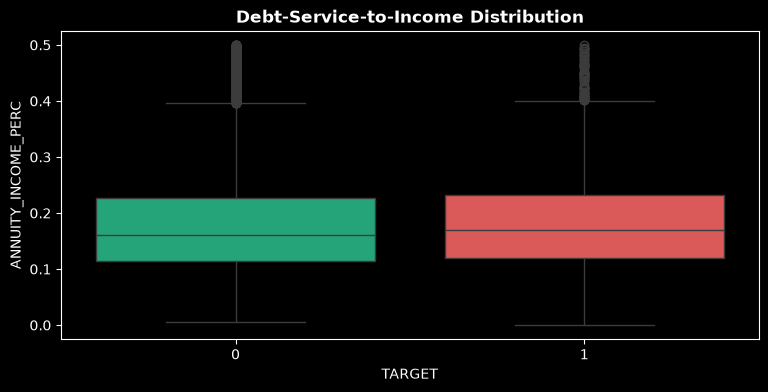

In [6]:
plt.figure(figsize=(9, 4))
sns.boxplot(x='TARGET', y='ANNUITY_INCOME_PERC', data=df_eng[df_eng['ANNUITY_INCOME_PERC'] < 0.5], palette=['#10B981', '#EF4444'])
plt.title('Debt-Service-to-Income Distribution', fontweight='bold')
plt.show()